# Test 5 — The winner's peak method, an adapted version, and a blend with the CNN

This notebook compares three approaches to PD detection under the same evaluation, and writes a Kaggle submission file for each:

| Approach | Description |
|---|---|
| **B0 — winner's method** | The 9 measurement-level peak features of the competition's 1st-place solution (Kaggle user mark4h), with LightGBM settings taken from that solution |
| **B1 — adapted method** | B0 plus 21 additional features: per-phase spread of peak counts, polarity counts, 45° phase windows, two extra sawtooth templates, height statistics, a symmetric-pair indicator and peak width |
| **Blend** | B1 (or B0, whichever is better in cross-validation) combined with the Test 4 aligned CNN, after calibrating both to the same probability scale |

**Evaluation:**
- Each **measurement** is one row (its three phases together), so grouping by measurement is automatic.
- **25 repeats × 5 folds** (125 models per approach). In each fold, one fold gives the out-of-fold (OOF) predictions, the **next fold is used only for early stopping**, and the remaining three train the model. This is the winner's design and keeps early stopping separate from evaluation.
- Results are reported at **measurement level** and at **signal level** (each measurement's prediction given to its three signals), the latter comparable with Tests 3 and 4 and with Kaggle.
- The internal test set (1,308 signals) stays unused.

**Pre-registered submission plan (decided before seeing results):** submit all three files; the approach with the best signal-level cross-validated MCC is the headline result, and all scores are reported.

**Inputs:** the committed output of `09_peak_features`, and (for the blend) the committed output of Test 4 after adding its prediction-saving cell. No GPU is needed.

## 1. Settings

In [1]:
import glob, json, warnings
warnings.filterwarnings('ignore', message='.*eval_set.*')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import matthews_corrcoef, confusion_matrix

N_REPEATS, N_FOLDS, SEED_BASE = 25, 5, 1000
EARLY_STOP = 100
LGB_PARAMS = dict(objective='binary', learning_rate=0.01, num_leaves=80, colsample_bytree=0.8,
                  subsample=0.8, subsample_freq=1, n_estimators=10000, verbose=-1)   # winner's settings
THRESHOLDS = np.arange(0.01, 0.99, 0.01)
OUT_DIR = '/kaggle/working'
print('LightGBM', lgb.__version__)

LightGBM 4.6.0


## 2. Load the peak tables

The check stops the notebook if the quick-test output (60 signals) is attached instead of the full run.

In [2]:
def find(name):
    m = glob.glob(f'/kaggle/input/**/{name}', recursive=True)
    assert m, f'{name} not found: attach the committed output of 09_peak_features'
    return m[0].rsplit('/', 1)[0]

D = find('peaks_train.parquet')
meta = pd.read_csv(f'{D}/meta_train.csv')
meta_k = pd.read_csv(f'{D}/meta_kaggle_test.csv')
assert len(meta) == 8712 and len(meta_k) == 20337, f'quick-test output attached ({len(meta)}, {len(meta_k)}): commit 09 with LIMIT = None'

cols = ['signal_id', 'id_measurement', 'phase']
peaks = pd.read_parquet(f'{D}/peaks_train.parquet').merge(meta[cols], on='signal_id')
peaks_k = pd.read_parquet(f'{D}/peaks_kaggle_test.parquet').merge(meta_k[cols], on='signal_id')
sig_stats = pd.read_csv(f'{D}/signals_train.csv')
print(f'Peaks: {len(peaks):,} labelled, {len(peaks_k):,} Kaggle test | '
      f'noise-floor fallback used for {sig_stats["fallback"].sum()} labelled signals')

Peaks: 1,298,370 labelled, 2,616,855 Kaggle test | noise-floor fallback used for 8 labelled signals


## 3. Measurement-level features

**Filter (from the winner):** peaks that are both very large (height > 50) and broad (ratio to the next point > 1/3) are removed, since they are typical of interference rather than PD.

**Quarters:** each peak's phase angle places it in a quarter of the voltage cycle: Q0 = 0–90°, Q1 = 90–180°, Q2 = 180–270°, Q3 = 270–360°. Q0 and Q2 are where the voltage magnitude is rising, where PD is most expected.

**B0 (winner's 9 features):** peak counts in Q0+Q2, in Q1+Q3 and in total; and, for peaks in Q0+Q2, the mean and standard deviation of height, the mean ratios to the next and previous points, the mean absolute offset of the opposite-polarity extreme, and the mean sawtooth error (template length 3).

**B1 additions (21):**
- **Per-phase spread** of Q0+Q2 peak counts across the three phases (max, min, standard deviation), since earlier tests showed cross-phase information matters.
- **Polarity:** positive and negative peak counts in Q0 and in Q2 separately.
- **45° windows:** peak counts in each eighth of the cycle.
- **Extra templates:** mean sawtooth error for template lengths 2 and 5.
- **Height statistics:** 90th percentile and maximum height in Q0+Q2.
- **Symmetric-pair indicator:** share of Q0+Q2 peaks whose opposite-polarity extreme is within 1 sample (a sign of ringing or symmetric interference pairs).
- **Width:** mean peak width in Q0+Q2.

In [3]:
B0_COLS = ['peak_count_Q13', 'abs_small_dist_to_min_mean_Q02', 'height_mean_Q02', 'height_std_Q02',
           'sawtooth_rmse_mean_Q02', 'peak_count_Q02', 'ratio_next_mean_Q02', 'ratio_prev_mean_Q02', 'peak_count_total']

def build_features(p, m):
    p = p[~((p['ratio_next'] > 1 / 3) & (p['height'] > 50))].copy()
    p['Q'] = (p['phase_deg'] // 90).astype(int).clip(0, 3)
    p['abs_dist'] = p['small_dist_to_min'].abs()
    f = pd.DataFrame(index=pd.Index(np.sort(m['id_measurement'].unique()), name='id_measurement'))
    q02 = p[p['Q'].isin([0, 2])]
    g = q02.groupby('id_measurement')
    # --- B0: the winner's 9 features (missing values left as NaN, as in the original)
    f['peak_count_Q02'] = g.size()
    f['peak_count_Q13'] = p[p['Q'].isin([1, 3])].groupby('id_measurement').size()
    f['peak_count_total'] = p.groupby('id_measurement').size()
    f['height_mean_Q02'] = g['height'].mean()
    f['height_std_Q02'] = g['height'].std()
    f['ratio_prev_mean_Q02'] = g['ratio_prev'].mean()
    f['ratio_next_mean_Q02'] = g['ratio_next'].mean()
    f['abs_small_dist_to_min_mean_Q02'] = g['abs_dist'].mean()
    f['sawtooth_rmse_mean_Q02'] = g['sawtooth_3'].mean()
    # --- B1 additions
    per_phase = q02.groupby(['id_measurement', 'phase']).size().unstack(fill_value=0).reindex(columns=[0, 1, 2], fill_value=0)
    per_phase = per_phase.reindex(f.index, fill_value=0)
    f['q02_count_phase_max'], f['q02_count_phase_min'], f['q02_count_phase_std'] = per_phase.max(1), per_phase.min(1), per_phase.std(1)
    for q in (0, 2):
        for s, name in ((1, 'pos'), (-1, 'neg')):
            f[f'{name}_count_Q{q}'] = p[(p['Q'] == q) & (p['sign'] == s)].groupby('id_measurement').size()
    bins = p.assign(b=(p['phase_deg'] // 45).astype(int).clip(0, 7)).groupby(['id_measurement', 'b']).size().unstack(fill_value=0)
    for b in range(8):
        f[f'count_{b * 45}deg'] = bins[b] if b in bins.columns else 0
    f['sawtooth2_mean_Q02'] = g['sawtooth_2'].mean()
    f['sawtooth5_mean_Q02'] = g['sawtooth_5'].mean()
    f['height_p90_Q02'] = g['height'].quantile(0.9)
    f['height_max_Q02'] = g['height'].max()
    f['sym_pair_share_Q02'] = g['abs_dist'].apply(lambda s: (s <= 1).mean())
    f['width_mean_Q02'] = g['width'].mean()
    extra_counts = [c for c in f.columns if c.startswith(('pos_', 'neg_', 'count_'))]
    f[extra_counts] = f[extra_counts].fillna(0)
    return f

F, F_k = build_features(peaks, meta), build_features(peaks_k, meta_k)
B1_COLS = B0_COLS + [c for c in F.columns if c not in B0_COLS]
print(f'B0: {len(B0_COLS)} features | B1: {len(B1_COLS)} features | measurements: {len(F)} labelled, {len(F_k)} Kaggle test')

B0: 9 features | B1: 30 features | measurements: 2904 labelled, 6779 Kaggle test


## 4. Labels and sets

A measurement is labelled PD if any of its phases is. The pool (original training and validation sets) is used for cross-validation; the internal test measurements are kept aside.

In [4]:
y_meas = meta.groupby('id_measurement')['target'].max()
meas_split = meta.groupby('id_measurement')['split'].first()
pool_ids = meas_split.index[meas_split.isin(['train', 'val'])].values
test_ids = meas_split.index[meas_split == 'test'].values
yp = y_meas.loc[pool_ids].values
pool_sig = meta[meta['id_measurement'].isin(pool_ids)]
print(f'Pool: {len(pool_ids)} measurements ({yp.sum()} PD), {len(pool_sig)} signals | internal test: {len(test_ids)} measurements')

Pool: 2468 measurements (165 PD), 7404 signals | internal test: 436 measurements


## 5. Cross-validation (25 repeats × 5 folds)

For each repeat, the pool measurements are split into 5 stratified folds with a different seed. For fold *k*: fold *k* gives OOF predictions, fold *k*+1 is used for early stopping, and the other three train the model. Kaggle-test and internal-test predictions are averaged over all 125 models.

In [5]:
def run_cv(cols):
    Xp, Xk, Xt = F.loc[pool_ids, cols].values, F_k[cols].values, F.loc[test_ids, cols].values
    n_models = N_REPEATS * N_FOLDS
    out = dict(oof=np.zeros((N_REPEATS, len(pool_ids))), kaggle=np.zeros(len(Xk)), test=np.zeros(len(Xt)),
               importance=np.zeros(len(cols)), iters=[])
    for r in range(N_REPEATS):
        fold = np.zeros(len(pool_ids), dtype=int)
        for k, (_, va) in enumerate(StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED_BASE + r).split(Xp, yp)):
            fold[va] = k
        for k in range(N_FOLDS):
            va, st = fold == k, fold == (k + 1) % N_FOLDS
            tr = ~(va | st)
            model = lgb.LGBMClassifier(**LGB_PARAMS, random_state=SEED_BASE + r)
            model.fit(Xp[tr], yp[tr], eval_set=[(Xp[st], yp[st])], callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])
            out['oof'][r, va] = model.predict_proba(Xp[va])[:, 1]
            out['kaggle'] += model.predict_proba(Xk)[:, 1] / n_models
            out['test'] += model.predict_proba(Xt)[:, 1] / n_models
            out['importance'] += model.booster_.feature_importance('gain') / n_models
            out['iters'].append(model.best_iteration_)
        if (r + 1) % 5 == 0:
            print(f'  repeat {r + 1}/{N_REPEATS} done')
    return out

results = {}
for name, cols in [('B0_winner', B0_COLS), ('B1_adapted', B1_COLS)]:
    print(name); results[name] = run_cv(cols)

B0_winner


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

  repeat 5/25 done


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

  repeat 10/25 done


...

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

  repeat 20/25 done


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

  repeat 25/25 done


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 6. Blend with the Test 4 CNN

Uses the saved Test 4 predictions (`test4_predictions.npz`), if attached. The CNN's per-signal probabilities are averaged over each measurement's three phases. Because the CNN (trained with class weighting) and LightGBM (trained without) produce probabilities on different scales, each is **calibrated** with a logistic fit on its OOF predictions before blending: `blend = w × CNN + (1 − w) × LightGBM`, with w chosen on the OOF predictions. Calibration and w are both chosen on the same OOF predictions, which makes the blend's OOF score slightly optimistic; this is noted in the results.

In [6]:
def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6); return np.log(p / (1 - p))

def calibrator(p_oof, y):
    lr = LogisticRegression(C=1e6).fit(logit(p_oof)[:, None], y)
    return lambda p: lr.predict_proba(logit(p)[:, None])[:, 1]

def to_signal(p_meas, ids, m):
    return m['id_measurement'].map(pd.Series(p_meas, index=ids)).values

def best_signal_cut(p_meas):
    ps, ys = to_signal(p_meas, pool_ids, pool_sig), pool_sig['target'].values
    scores = [matthews_corrcoef(ys, ps > t) for t in THRESHOLDS]
    i = int(np.argmax(scores)); return scores[i], float(THRESHOLDS[i])

npz = glob.glob('/kaggle/input/**/test4_predictions.npz', recursive=True)
if npz:
    d = np.load(npz[0])
    def meas_mean(values, sig_ids, m, ids):
        s = pd.Series(values, index=sig_ids)
        return m.assign(p=m['signal_id'].map(s)).groupby('id_measurement')['p'].mean().loc[ids].values
    cnn_pool = meas_mean(d['oof_CNN_12feat_aligned'], d['signal_id'], meta, pool_ids)
    cnn_kag = meas_mean(d['kaggle_CNN_12feat_aligned'], d['signal_id_kaggle'], meta_k, F_k.index.values)
    base = max(results, key=lambda k: best_signal_cut(results[k]['oof'].mean(0))[0])
    lgb_pool, lgb_kag = results[base]['oof'].mean(0), results[base]['kaggle']
    cal_c, cal_l = calibrator(cnn_pool, yp), calibrator(lgb_pool, yp)
    best = max(((best_signal_cut(w * cal_c(cnn_pool) + (1 - w) * cal_l(lgb_pool))[0], w) for w in [0, 0.25, 0.5, 0.75, 1]))
    W = best[1]
    blend_pool = W * cal_c(cnn_pool) + (1 - W) * cal_l(lgb_pool)
    results['Blend'] = dict(oof=blend_pool[None, :], kaggle=W * cal_c(cnn_kag) + (1 - W) * cal_l(lgb_kag), weight=W, base=base)
    print(f'Blend of CNN and {base}: chosen CNN weight w = {W}')
else:
    print('test4_predictions.npz not attached: blend skipped (add the saving cell to Test 4, commit, and attach its output)')

test4_predictions.npz not attached: blend skipped (add the saving cell to Test 4, commit, and attach its output)


## 7. Results

- **Measurement MCC per repeat (mean ± SD):** each repeat's OOF predictions at their own best cut-off; the SD shows the variation across the 25 repeats.
- **Ensemble OOF MCC (measurement):** OOF predictions averaged over the 25 repeats.
- **Signal-level MCC:** each measurement's ensemble prediction given to its three signals, at the best signal-level cut-off. **This is the number comparable with Tests 3 and 4 and with Kaggle.**

In [7]:
def meas_cut(p, y):
    scores = [matthews_corrcoef(y, p > t) for t in THRESHOLDS]; return max(scores)

rows, settings = [], {}
for name, r in results.items():
    ens = r['oof'].mean(0)
    per_rep = [meas_cut(r['oof'][i], yp) for i in range(len(r['oof']))]
    sig_mcc, cut = best_signal_cut(ens)
    pred = to_signal(ens, pool_ids, pool_sig) > cut
    tn, fp, fn, tp = confusion_matrix(pool_sig['target'].values, pred).ravel()
    settings[name] = cut
    rows.append({'Approach': name, 'Meas. MCC per repeat (mean)': round(np.mean(per_rep), 3),
                 'Meas. MCC per repeat (SD)': round(np.std(per_rep), 3) if len(per_rep) > 1 else None,
                 'Ensemble OOF MCC (measurement)': round(meas_cut(ens, yp), 3),
                 'Signal-level MCC': round(sig_mcc, 3), 'Cut-off': round(cut, 2),
                 'Recall': f'{tp / (tp + fn):.1%}', 'Precision': f'{tp / (tp + fp):.1%}', 'False alarms': f'{fp} of {fp + tn}'})
summary5 = pd.DataFrame(rows)
summary5.to_csv(f'{OUT_DIR}/test5_summary.csv', index=False)

reference = pd.DataFrame({'Approach': ['Test 4: CNN_12feat_aligned', 'Test 4: LGBM_12feat_aligned', 'Test 4: Blend_aligned'],
                          'Signal-level MCC': [0.736, 0.714, 0.749]})
print('Test 4 reference (signal level, phase blending):'); print(reference.to_string(index=False)); print()
summary5

Test 4 reference (signal level, phase blending):
                   Approach  Signal-level MCC
 Test 4: CNN_12feat_aligned             0.736
Test 4: LGBM_12feat_aligned             0.714
      Test 4: Blend_aligned             0.749



,Approach,Meas. MCC per repeat (mean),Meas. MCC per repeat (SD),Ensemble OOF MCC (measurement),Signal-level MCC,Cut-off,Recall,Precision,False alarms
0,B0_winner,0.724,0.010,0.751,0.726,0.39,71.2%,77.2%,95 of 6952
1,B1_adapted,0.750,0.013,0.769,0.753,0.34,74.8%,78.8%,91 of 6952


## 8. What the adapted LightGBM relies on

Average gain over the 125 B1 models. Features added in this project are marked with ★.

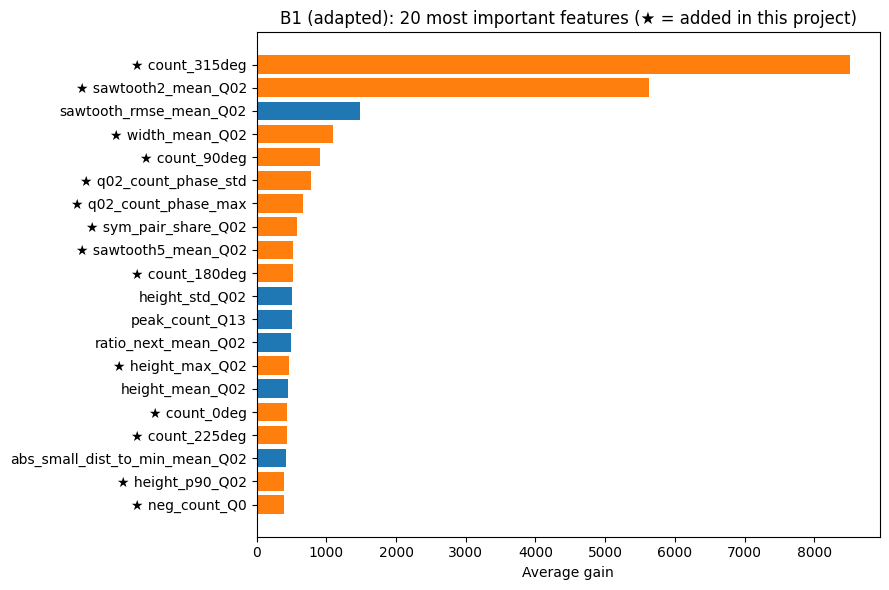

In [8]:
imp = pd.Series(results['B1_adapted']['importance'], index=B1_COLS).sort_values(ascending=False).head(20)
labels = [('★ ' if c not in B0_COLS else '') + c for c in imp.index]
plt.figure(figsize=(9, 6))
plt.barh(labels[::-1], imp.values[::-1], color=['tab:orange' if c not in B0_COLS else 'tab:blue' for c in imp.index][::-1])
plt.xlabel('Average gain'); plt.title('B1 (adapted): 20 most important features (★ = added in this project)')
plt.tight_layout(); plt.show()

## 9. Submission files

For each approach, the measurement-level ensemble prediction is compared with its signal-level cut-off from section 7 and given to all three signals of each measurement. Following the pre-registered plan, **submit all files** and report every score; the approach with the best signal-level MCC in section 7 is the headline.

In [9]:
for name, r in results.items():
    p_sig = to_signal(r['kaggle'], F_k.index.values, meta_k)
    sub = pd.DataFrame({'signal_id': meta_k['signal_id'], 'target': (p_sig > settings[name]).astype(int)})
    sub.to_csv(f'{OUT_DIR}/submission_{name}.csv', index=False)
    print(f'submission_{name}.csv: {sub["target"].sum()} predicted PD ({sub["target"].mean():.1%})')

headline = summary5.sort_values('Signal-level MCC', ascending=False)['Approach'].iloc[0]
print('\nHeadline approach (best signal-level CV MCC):', headline)
np.savez(f'{OUT_DIR}/test5_predictions.npz', pool_ids=pool_ids, kaggle_ids=F_k.index.values,
         **{f'oof_{k}': v['oof'].mean(0) for k, v in results.items()}, **{f'kaggle_{k}': v['kaggle'] for k, v in results.items()})
with open(f'{OUT_DIR}/test5_settings.json', 'w') as f:
    json.dump({'cutoffs': settings, 'headline': headline, 'blend_weight': results.get('Blend', {}).get('weight'),
               'blend_base': results.get('Blend', {}).get('base'),
               'median_best_iteration': {k: int(np.median(v['iters'])) for k, v in results.items() if 'iters' in v}}, f, indent=2)

submission_B0_winner.csv: 741 predicted PD (3.6%)
submission_B1_adapted.csv: 807 predicted PD (4.0%)

Headline approach (best signal-level CV MCC): B1_adapted


## 10. Internal test evaluation (switched off)

Kept for the very end, once the final model is chosen.

In [10]:
RUN_FINAL_TEST = False
if RUN_FINAL_TEST:
    FINAL = headline if headline != 'Blend' else results['Blend']['base']
    test_sig = meta[meta['id_measurement'].isin(test_ids)]
    pred = to_signal(results[FINAL]['test'], test_ids, test_sig) > settings[FINAL]
    t = test_sig['target'].values; tn, fp, fn, tp = confusion_matrix(t, pred).ravel()
    print(f'{FINAL} internal test MCC: {matthews_corrcoef(t, pred):.3f} | PD caught {tp} of {tp + fn} | false alarms {fp} of {fp + tn}')
else:
    print('Internal test evaluation is switched off.')

Internal test evaluation is switched off.
